In [1]:
from importlib.metadata import version

print("torch version: ", version("torch"))
print("tokenizers version: ", version("tokenizers"))
print("accelerate version: ", version("accelerate"))

torch version:  2.7.0+cu128
tokenizers version:  0.22.0
accelerate version:  1.10.1


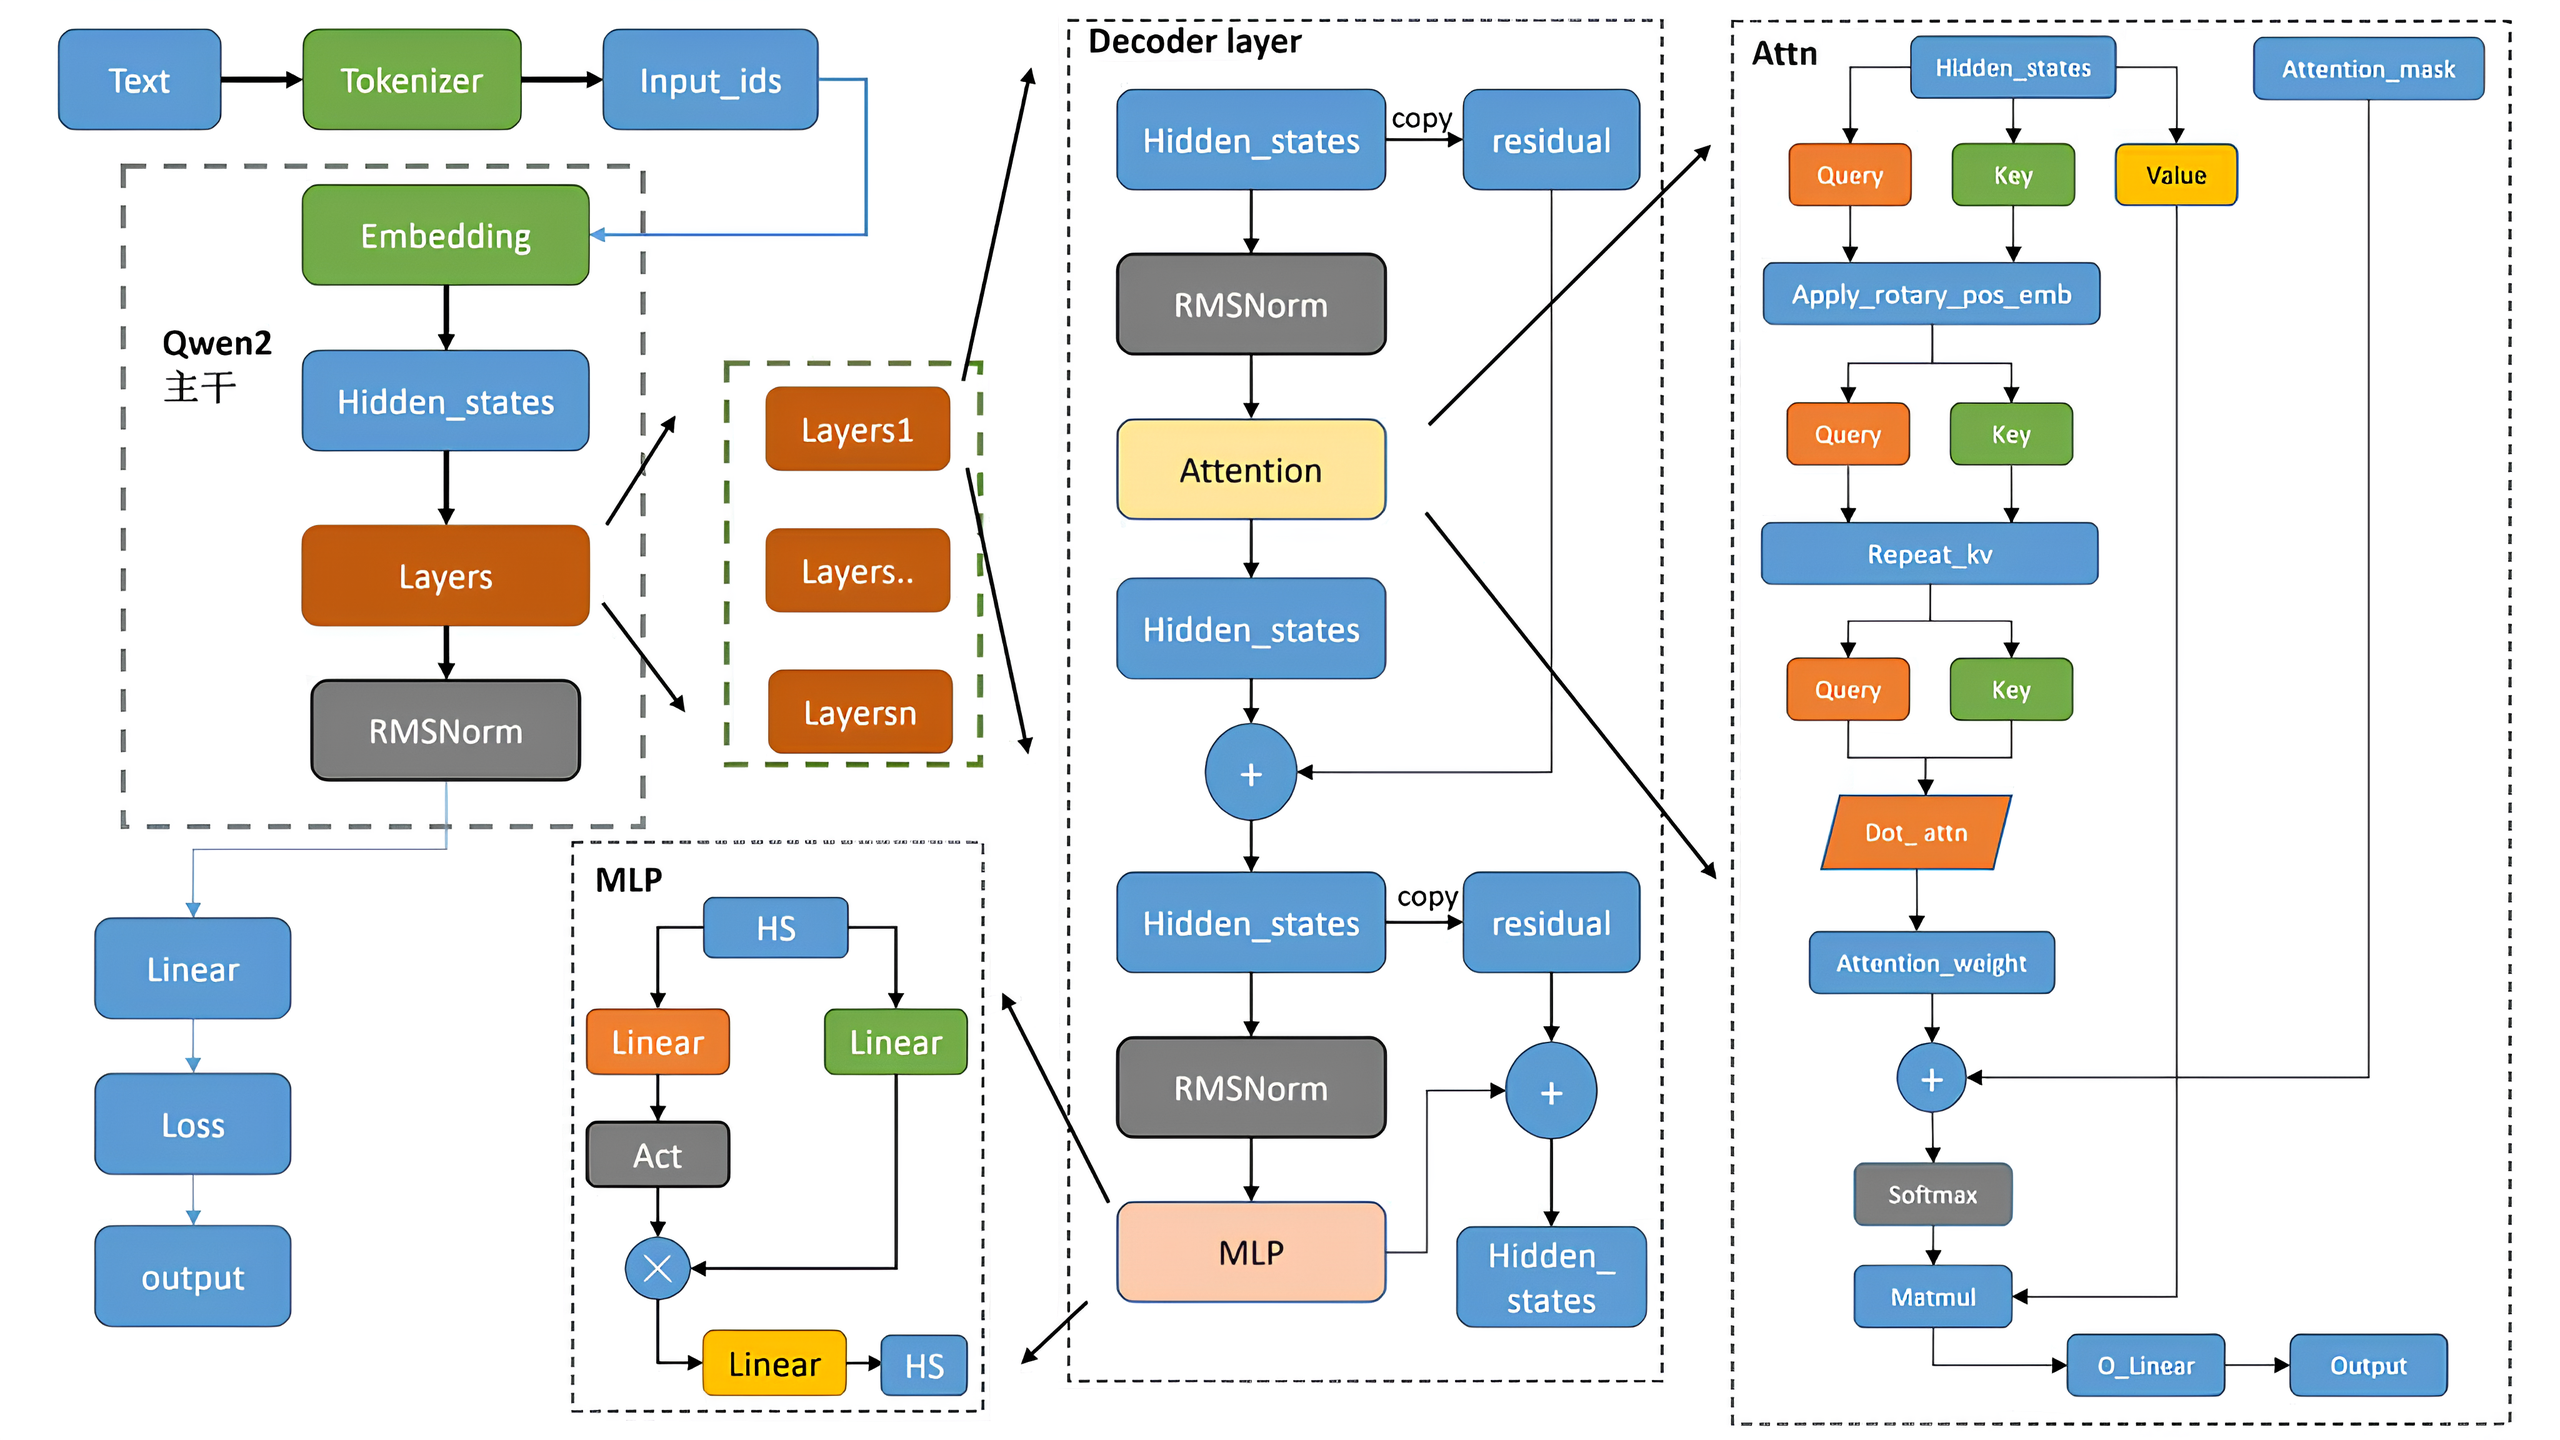

In [1]:
from IPython.display import Image, display

# 替换为你的桌面路径（关键！）
# Windows 示例: 'C:/Users/你的用户名/Desktop/MLA-Prefill.png'
# macOS/Linux 示例: '/Users/你的用户名/Desktop/MLA-Prefill.png'
image_path = r'C:/Users/1/Desktop/DeepSeek-Ditill-Qwen.png'  # ← 修改这里！

display(Image(filename=image_path))

# 手撕DeepSeek-Distill-Qwen(适用于1.5B/7B/14B/32Bs)

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import os
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"

import json
from pathlib import Path
from tokenizers import Tokenizer
from typing import List, Optional, Dict, Union
from dataclasses import dataclass
from accelerate import init_empty_weights, load_checkpoint_and_dispatch

# 定义模型参数

In [4]:
@dataclass
class ModelConfig:
    hidden_size: int                  # 隐藏层维度
    num_attention_heads: int          # 多头注意力的头数         
    num_key_value_heads: int          # GQA的KV头数
    num_hidden_layers: int            # decoder Layer的层数
    intermediate_size: int            # FFN中间层的维度
    rope_theta: float                 # ROPE的base
    rms_norm_eps: float               # RMSNorm的epsilon
    vocab_size: int                   # 词汇表大小
    tie_word_embeddings: bool         # 是否要共享输入层和输出层的embedding

# 定义模型

In [5]:
class RotaryEmbedding(nn.Module):
    def __init__(self, config: ModelConfig):
        super().__init__()
        d = config.hidden_size // config.num_attention_heads # 每个头的维度
        t = config.rope_theta
        r = torch.arange(0, d, 2)
        self.inv_freq = 1.0 / (t ** (r / d)).float()    # 计算base^(-2i/d) 

    def forward(self, x, position_ids):
        inv_freq = self.inv_freq.to(x.device)

        position_ids = position_ids.unsqueeze(-1)
        freqs = position_ids * inv_freq                 # 计算每一个位置的inv_freq, m*theta            
        emb = torch.cat([freqs, freqs], dim=-1)
        cos = emb.cos().to(x.dtype)
        sin = emb.sin().to(x.dtype)
        return cos, sin


class CausalSelfAttention(nn.Module):
    '''带掩码的多头注意力机制'''
    def __init__(self, config):
        super().__init__()

        self.n_heads = config.num_attention_heads
        self.n_kv_heads = config.num_key_value_heads

        self.n_embed = config.hidden_size
        self.n_embed_per_head = config.hidden_size // config.num_attention_heads
        self.n_kv_embed = config.num_key_value_heads * self.n_embed_per_head

        self.q_proj = nn.Linear(self.n_embed, self.n_embed, bias=True)   # 注意Qwen的Wq, Wk, Wv是有bias的
        self.k_proj = nn.Linear(self.n_embed, self.n_kv_embed, bias=True)
        self.v_proj = nn.Linear(self.n_embed, self.n_kv_embed, bias=True)
        self.o_proj = nn.Linear(self.n_embed, self.n_embed, bias=False)  # O矩阵是没有bias的

    def forward(self, x, cos, sin):
        batch_size, seq_len, hidden_dim = x.size()

        q = self.q_proj(x)
        k = self.k_proj(x)
        v = self.v_proj(x)

        q = q.view(batch_size, seq_len, self.n_heads, self.n_embed_per_head).transpose(1, 2)
        k = k.view(batch_size, seq_len, self.n_kv_heads, self.n_embed_per_head).transpose(1, 2)
        v = v.view(batch_size, seq_len, self.n_kv_heads, self.n_embed_per_head).transpose(1, 2)

        q, k = self._apply_rotary_pos_emb(q, k, cos, sin)   # 对，Q, K做旋转位置编码

        if self.n_kv_heads < self.n_heads:       # GQA, 注意要用interleave repeat，也就是[1,2,3]=>[1,1,1,2,2,2,3,3,3]
            num_repeat = self.n_heads // self.n_kv_heads
            k = k.repeat_interleave(num_repeat, dim=1)
            v = v.repeat_interleave(num_repeat, dim=1)

        att_out = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        att_out = att_out.transpose(1, 2).contiguous().view(batch_size, seq_len, hidden_dim)
        output = self.o_proj(att_out)
        return output

    @staticmethod
    def _apply_rotary_pos_emb(q, k, cos, sin):
        '''Q， K分别乘上旋转矩阵'''
        cos = cos.unsqueeze(1)
        sin = sin.unsqueeze(1)
        q_embed = (q * cos) + (CausalSelfAttention._rotate_half(q) * sin)
        k_embed = (k * cos) + (CausalSelfAttention._rotate_half(k) * sin)
        return q_embed, k_embed

    @staticmethod
    def _rotate_half(x):
        '''前一半的维度和后一半的维度组合成pair，每一个pair分别做ROPE'''
        x1 = x[..., : x.shape[-1] // 2]
        x2 = x[..., x.shape[-1] // 2 :]
        return torch.cat((-x2, x1), dim=-1)


class RMSNorm(nn.Module):
    def __init__(self, n_embed, eps=1e-6):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(n_embed))
        self.epsilon = eps

    def forward(self, x):
        '''RMSNorm的代码'''
        input_dtype = x.dtype
        x = x.to(torch.float32)
        variance = x.pow(2).mean(-1, keepdim=True)
        x = x * torch.rsqrt(variance + self.epsilon)
        return self.weight * x.to(input_dtype)


class MLP(nn.Module):
    def __init__(self, config):
        '''SwiGLU, 三个参数矩阵，门控矩阵，升维矩阵，降维矩阵'''
        super().__init__()
        self.gate_proj = nn.Linear(config.hidden_size, config.intermediate_size, bias=False)
        self.up_proj = nn.Linear(config.hidden_size, config.intermediate_size, bias=False)
        self.down_proj = nn.Linear(config.intermediate_size, config.hidden_size, bias=False)

    def forward(self, x):
        return self.down_proj(F.silu(self.gate_proj(x)) * self.up_proj(x))


class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        n_embed, eps = config.hidden_size, config.rms_norm_eps
        self.input_layernorm = RMSNorm(n_embed=n_embed, eps=eps)
        self.self_attn = CausalSelfAttention(config)
        self.post_attention_layernorm = RMSNorm(n_embed=n_embed, eps=eps)
        self.mlp = MLP(config)

    def forward(self, x, cos, sin):
        '''一个decoder layer由一个mask self-attention+FFN+2个rmsnorm组成'''
        x = x + self.self_attn(self.input_layernorm(x), cos, sin)
        x = x + self.mlp(self.post_attention_layernorm(x))
        return x


class Transformer(nn.Module):
    '''GPT主体代码'''
    def __init__(self, config):
        super().__init__()
        self.embed_tokens = nn.Embedding(config.vocab_size, config.hidden_size)
        self.rotary_emb = RotaryEmbedding(config)
        self.layers = nn.ModuleList(Block(config) for _ in range(config.num_hidden_layers))
        self.norm = RMSNorm(config.hidden_size, eps=config.rms_norm_eps)

    def forward(self, x, position_ids):
        cos, sin = self.rotary_emb(x, position_ids)
        for layer in self.layers:
            x = layer(x, cos, sin)
        x = self.norm(x) 
        return x

# 从本地文件加载模型

In [6]:
class ModelHub:
    '''类似transformers库的功能（简化版的实现）'''
    @classmethod
    def from_pretrained(cls, repo_id, device_map='auto'):
        
        # 本地模型的路径
        model_path = Path(repo_id)

        # 加载模型 Config, os.path.join(a, b)
        with open(model_path / "config.json", "r") as f:
            config_data = json.load(f)

        llm_config = {k:v for k, v in config_data.items() if k in ModelConfig.__annotations__}
        model_config = ModelConfig(**llm_config)

        with init_empty_weights(): # 不消耗实际物理内存去初始化一个模型，只有形状和类型等信息，不存储任何实际的数据
            model = cls(model_config)

        return load_checkpoint_and_dispatch(
            model,
            model_path,
            dtype=torch.bfloat16,
            device_map=device_map,
            no_split_module_classes=['Block']
        )

# 定义模型的输入和输出，以及递归解码的逻辑

In [7]:
class DeepSeekR1Distilled(nn.Module, ModelHub):
    def __init__(self, config):
        super().__init__()
        self.config = config
        
        # 初始化模型
        self.model = Transformer(config)

        self.lm_head = None
        # 如果不做共享
        if not config.tie_word_embeddings:
            self.lm_head = nn.Linear(config.hidden_size, config.vocab_size, bias=False)

    def _get_postion_ids(self, input_ids):
        '''获取输入位置的id'''
        batch_size, seq_len = input_ids.shape
        device = input_ids.device
        position_ids = torch.arange(seq_len, dtype=torch.long, device=device) # [seq_len]
        position_ids = position_ids.unsqueeze(0).expand(batch_size, -1) #[batch_size, seq_len], 方便做 ROPE 得运算
        return position_ids
    
    def forward(self, input_ids):
        '''定义模型的主代码'''
        x = self.model.embed_tokens(input_ids) # ids => embedding
        position_ids = self._get_postion_ids(input_ids)
        x = self.model(x=x, position_ids=position_ids) # [batch_size, seq_len, hidden_size]

        # 如果权重共享，就用输入层的weight来预测输出
        if self.lm_head is None:
            logits = torch.matmul(x, self.model.embed_tokens.weight.T)
        else:
            logits = self.lm_head(x)
        return logits
        
    def generate(self, input_ids, max_new_tokens=128, temperature=0.0):
        '''定义核心的解码逻辑'''
        eos_token = tokenizer.encode("<｜end▁of▁sentence｜>").ids
        for _ in range(max_new_tokens):
            logits = self.forward(input_ids=input_ids) # [batch_size, seq_len, vocab_size]
            last_logits = logits[:, -1, :] # 取最后一个token，就是预测token，[batch_size, vocab_size]
            if temperature == 0.0:
                next_token = last_logits.argmax(dim=-1, keepdim=True) # 贪心解码
            else:
                scaled_logits = last_logits / temperature 
                probs = F.softmax(scaled_logits, dim=-1)
                next_token = torch.multinomial(probs, num_samples=1) # 按概率采样
            if next_token[0].tolist()[0] in eos_token:   # 如果遇到了eos_token，就停止解码
                break
            input_ids = torch.cat([input_ids, next_token], dim=1) # 拼接预测出来新的token并继续下一次解码
            output_text = tokenizer.decode(next_token[0].tolist()) # 解码当前的token, 并流式输出
            print(output_text, end='')

# 加载模型

In [8]:
model_name = "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B"
model = DeepSeekR1Distilled.from_pretrained(repo_id=model_name, device_map='auto').to("cuda")

# 加载tokenizer

In [9]:
tokenizer = Tokenizer.from_pretrained(model_name)

In [10]:
# 给一个输入
prompt = 'what is 5^0.5?'
input_ids = tokenizer.encode(prompt).ids
input_ids = torch.tensor([input_ids], dtype=torch.long).to("cuda")

In [13]:
# 解码输出
model.generate(input_ids, max_new_tokens=1024, temperature=0.6)

<think>
I need to find the value of 5 raised to the power of 0.5.

First, I recognize that 0.5 is equivalent to 1/2. Therefore, 5^0.5 is the same as the square root of 5.

To calculate the square root of 5, I know it's an irrational number, meaning it cannot be expressed exactly as a simple fraction or a terminating decimal. However, I can approximate its value.

Using a calculator, I determine that the square root of 5 is approximately 2.23607.

Thus, 5^0.5 equals approximately 2.23607.
</think>

To find the value of \(5^{0.5}\), follow these steps:

1. **Understand the Exponent:**
   
   The exponent \(0.5\) is equivalent to \(\frac{1}{2}\).

2. **Rewrite the Expression:**
   
   \[
   5^{0.5} = 5^{\frac{1}{2}}
   \]

3. **Interpret the Exponent:**
   
   An exponent of \(\frac{1}{2}\) represents the square root of the base. Therefore:

   \[
   5^{\frac{1}{2}} = \sqrt{5}
   \]

4. **Calculate the Square Root:**
   
   The square root of \(5\) is an irrational number. Its approximate

In [12]:
import math
math.sqrt(5)

2.23606797749979